In [72]:
import os
os.environ['SPS_HOME'] = '/home/vmehta/honours-project/code/src/fsps'

import numpy as np
import matplotlib.pyplot as plt
import fsps
import pickle as pkl
from astropy.io import fits
plt.style.use('thesis')

Going through an iterative process of understanding model performance as a function of the number of SFH labels, SNR = [500, 200, 100, 50]. 

In [73]:
# generating synthetic galaxy libraries of varying label binning
sp = fsps.StellarPopulation(
    sfh=0,
    imf_type=1,
    zmet = 10,
    add_dust_emission=False,
    nebemlineinspec=False,
)

w,s = sp.get_spectrum()
ages = sp.ssp_ages
w = w[470:2137]
s = s[:, 470:2137]

# define a function to generate logarithmically spaced bins for the labels
def binning(nbins):
    bin_arr = np.logspace(5, 10.15, nbins+1)
    bins = np.log10(bin_arr)

    digitized = np.digitize(ages, bins) - 1  # convert to 0-based bin indices
    n_bins = len(bins) - 1
    avg_spectra = []
    for i in range(n_bins):
        mask = digitized == i
        if not np.any(mask):
            raise ValueError(f"No SSP ages fall into bin {i} [{bins[i]:.2f}, {bins[i+1]:.2f}]")
        avg_spectra.append(s[mask].mean(axis=0))
    avg_spectra = np.vstack(avg_spectra)

    np.save(f'/home/vmehta/honours-project/code/data/sfh_binning/{nbins}_bins.npy', avg_spectra)
    print(f"Saved {avg_spectra.shape[0]} binned spectra on {avg_spectra.shape[1]} wavelengths.")
    
    return

In [74]:
# save file
binning(3)

Saved 3 binned spectra on 1667 wavelengths.


In [66]:
# looking at the linear coefficients for the labels

class load_model:
    def __init__(self, file, snr, nbins):
        self.wavs = np.load(f'/avatar/vmehta/binning-tests/{file}/{file}_wavelength.npy')
        self.spec = np.load(f'/avatar/vmehta/binning-tests/{file}/{file}_snr{snr}_spectra.npy')
        self.labels = fits.getdata(f'/avatar/vmehta/binning-tests/{file}/{file}_labels.fits')
        self.model = pkl.load(open(f'/avatar/vmehta/binning-tests/{file}/snr{snr}_model.pkl', 'rb'))
        self.pred = np.load(f'/avatar/vmehta/binning-tests/{file}/snr{snr}_pred.npy')
        self.true = np.load(f'/avatar/vmehta/binning-tests/{file}/snr{snr}_true.npy')
        self.nbins = nbins
        return

def linear_coeffs(m, nbins):
    coeffs = m['theta'][:,1:nbins+1]
    return coeffs


In [67]:
snr500 = load_model('sfh_500_2bins_20260313_134809', 500, 2)
snr200 = load_model('sfh_500_2bins_20260313_134809', 200, 2)
snr100 = load_model('sfh_500_2bins_20260313_134809', 100, 2)
snr50 = load_model('sfh_500_2bins_20260313_134809', 50, 2)

/tmp/ipykernel_3263397/4282463876.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  self.model = pkl.load(open(f'/avatar/vmehta/binning-tests/{file}/snr{snr}_model.pkl', 'rb'))


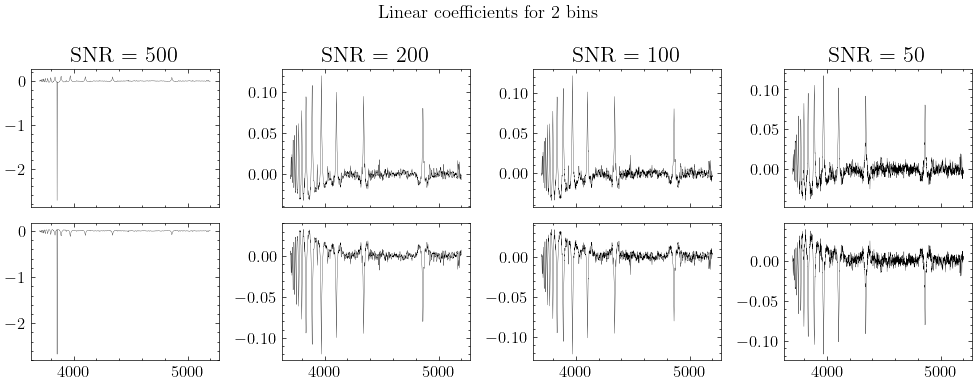

In [70]:
fig, ax = plt.subplots(2, 4, figsize=(10,4), sharex=True)
for n,s in enumerate([snr500, snr200, snr100, snr50]):
    for i in range(2):
        ax[i,n].plot(s.wavs, linear_coeffs(s.model, s.nbins)[:,i], linewidth=0.2, color='k')
ax[0,0].set_title('SNR = 500')
ax[0,1].set_title('SNR = 200')
ax[0,2].set_title('SNR = 100')
ax[0,3].set_title('SNR = 50')
fig.suptitle(f'Linear coefficients for {snr500.nbins} bins')
plt.tight_layout()
plt.show()

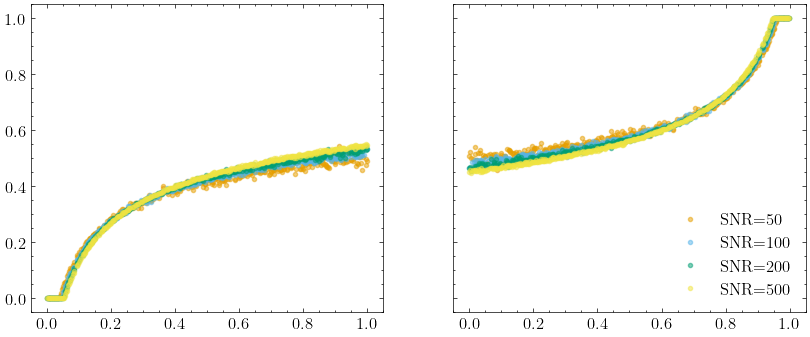

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)
for s in [snr50, snr100, snr200, snr500]:
    for i in range(2):
        ax[i].plot(s.true[:,i], s.pred[:,i], '.', alpha=0.5)
ax[1].legend(['SNR=50', 'SNR=100', 'SNR=200', 'SNR=500'], loc='lower right')

In [75]:
snr500 = load_model('sfh_500_3bins_20260313_140527', 500, 3)
snr200 = load_model('sfh_500_3bins_20260313_140527', 200, 3)
snr100 = load_model('sfh_500_3bins_20260313_140527', 100, 3)
snr50 = load_model('sfh_500_3bins_20260313_140527', 50, 3)

/tmp/ipykernel_3263397/4282463876.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  self.model = pkl.load(open(f'/avatar/vmehta/binning-tests/{file}/snr{snr}_model.pkl', 'rb'))


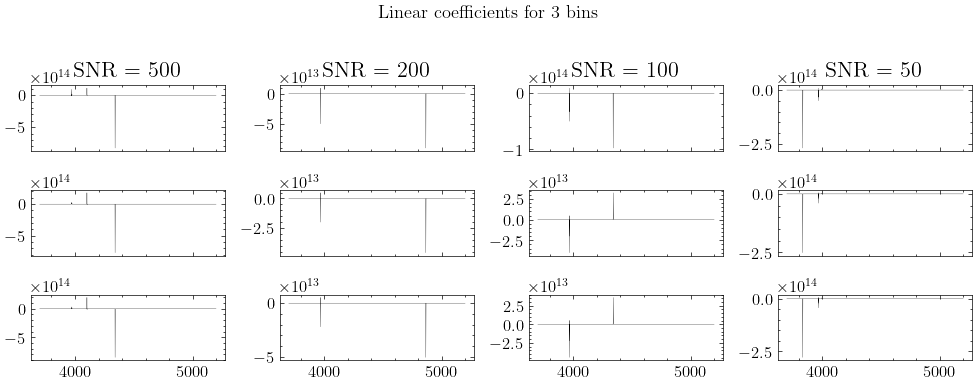

In [76]:
fig, ax = plt.subplots(3, 4, figsize=(10,4), sharex=True)
for n,s in enumerate([snr500, snr200, snr100, snr50]):
    for i in range(3):
        ax[i,n].plot(s.wavs, linear_coeffs(s.model, s.nbins)[:,i], linewidth=0.2, color='k')
ax[0,0].set_title('SNR = 500')
ax[0,1].set_title('SNR = 200')
ax[0,2].set_title('SNR = 100')
ax[0,3].set_title('SNR = 50')
fig.suptitle(f'Linear coefficients for {snr500.nbins} bins')
plt.tight_layout()
plt.show()

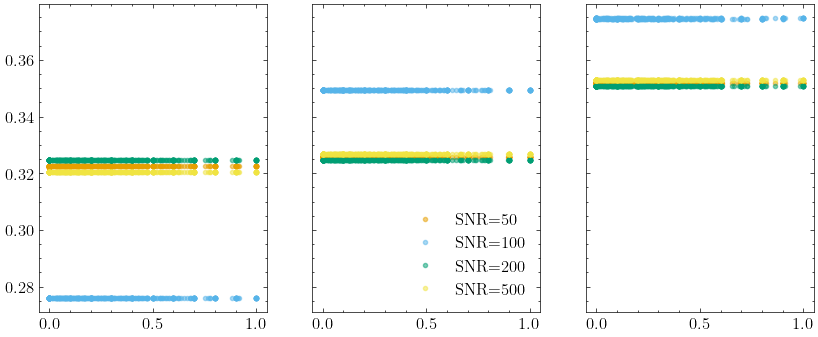

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(10,4), sharex=True, sharey=True)
for s in [snr50, snr100, snr200, snr500]:
    for i in range(3):
        ax[i].plot(s.true[:,i], s.pred[:,i], '.', alpha=0.5)
ax[1].legend(['SNR=50', 'SNR=100', 'SNR=200', 'SNR=500'], loc='lower right')